# **Name:** Vaishnavi Goyal  
# **SRN:** PES2UG24CS571

# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [3]:
# TODO 1: choropleth of total_gdp
fig_total = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="total_gdp",
    hover_name="country",
    title="Total GDP by Country (2007)",
    color_continuous_scale="Viridis"
)
fig_total.show()

# TODO 2: choropleth of gdpPercap
fig_rate = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="gdpPercap",
    hover_name="country",
    title="GDP per Capita by Country (2007)",
    color_continuous_scale="Viridis"
)
fig_rate.show()

# TODO 3: top 5 countries by each -- print both lists
top_total = gap_latest.nlargest(5, "total_gdp")[["country", "total_gdp"]]
top_rate = gap_latest.nlargest(5, "gdpPercap")[["country", "gdpPercap"]]
print("Top 5 by total GDP:\n", top_total)
print("\nTop 5 by GDP per capita:\n", top_rate)


Top 5 by total GDP:
            country     total_gdp
134  United States  1.293446e+13
24           China  6.539501e+12
66           Japan  4.035135e+12
58           India  2.722925e+12
47         Germany  2.650871e+12

Top 5 by GDP per capita:
            country    gdpPercap
95          Norway  49357.19017
71          Kuwait  47306.98978
113      Singapore  47143.17964
134  United States  42951.65309
62         Ireland  40675.99635


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

_Your answer:_ The top-five lists differ because total GDP is strongly affected by population size, while GDP per capita measures output per person. I would use the **GDP-per-capita (rate) map** when the question is about development or economic level per person, because it avoids letting population size dominate the visual comparison.


## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

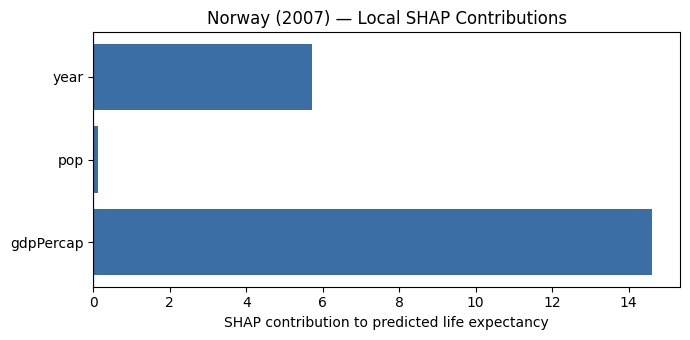

In [4]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values

# TODO 1: fit the model
rf = RandomForestRegressor(n_estimators=300, random_state=0)
rf.fit(X_model, y_model)

# TODO 2: SHAP explainer + values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

# TODO 3: find Norway's row, plot its SHAP contributions
row_idx = gapminder.index[(gapminder["country"] == "Norway") & (gapminder["year"] == 2007)][0]
row_position = gapminder.index.get_loc(row_idx)
vals = np.asarray(shap_values)[row_position]

features = ["gdpPercap", "pop", "year"]
fig, ax = plt.subplots(figsize=(7, 3.5))
ypos = np.arange(len(features))
bar_colors = ["#3b6ea5" if v >= 0 else "#b5432e" for v in vals]
ax.barh(ypos, vals, color=bar_colors)
ax.set_yticks(ypos)
ax.set_yticklabels(features)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP contribution to predicted life expectancy")
ax.set_title("Norway (2007) — Local SHAP Contributions")
plt.tight_layout()
plt.show()


**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

_Your answer:_ For Norway in 2007, **GDP per capita (`gdpPercap`)** makes by far the largest positive contribution to the prediction. In this fitted model, population and year also contribute positively, so there is no negative SHAP contribution among the three features for Norway's 2007 row. The feature with the largest local positive contribution is also the feature with the largest global Random Forest importance here, but global importance does not provide the signed, country-specific explanation that SHAP provides.


## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

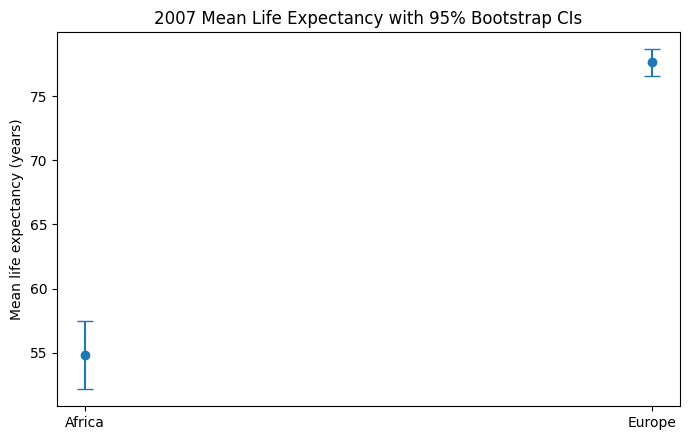

In [5]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    # TODO 1: resample `values` with replacement n_boot times, take the mean each time,
    # then return (overall mean, 2.5th percentile of boot means, 97.5th percentile)
    values = np.asarray(values)
    boot_means = np.array([
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(n_boot)
    ])
    return (
        values.mean(),
        np.percentile(boot_means, 2.5),
        np.percentile(boot_means, 97.5)
    )

# TODO 2: compute CIs for two continents of your choice
continent_a, continent_b = "Africa", "Europe"
values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)

# TODO 3: plot both as error bars (mean +/- CI half-width) on one chart
means = [result_a[0], result_b[0]]
lower = [result_a[0] - result_a[1], result_b[0] - result_b[1]]
upper = [result_a[2] - result_a[0], result_b[2] - result_b[0]]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    [continent_a, continent_b],
    means,
    yerr=[lower, upper],
    fmt="o",
    capsize=6
)
ax.set_ylabel("Mean life expectancy (years)")
ax.set_title("2007 Mean Life Expectancy with 95% Bootstrap CIs")
plt.tight_layout()
plt.show()


**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

_Your answer:_ **Africa** has the wider confidence interval: its bootstrap interval is about 52.15–57.44 years, compared with about 76.57–78.65 years for Europe. Africa has both a larger country-level standard deviation and a larger sample size than Europe in this dataset, so the main reason for the wider interval here is the **much higher variation (SD)**, not a smaller sample size. In general, confidence-interval width reflects both variation and sample size through the standard error.


## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

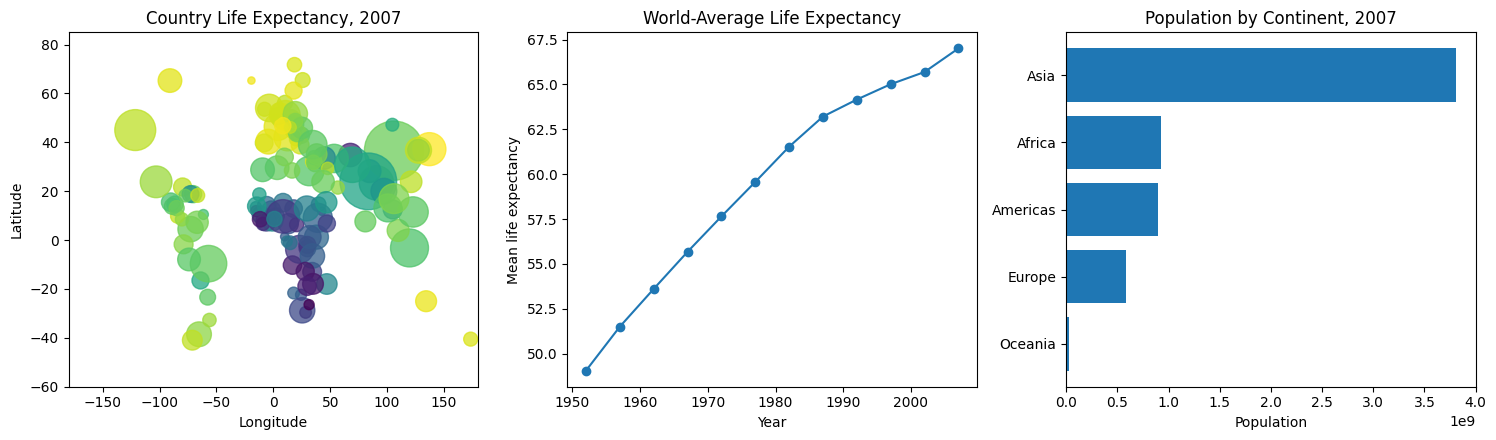

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# TODO 1: map-style scatter (axes[0])
axes[0].scatter(
    gap_latest["centroid_lon"],
    gap_latest["centroid_lat"],
    c=gap_latest["lifeExp"],
    s=np.sqrt(gap_latest["pop"]) / 20,
    alpha=0.75
)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Country Life Expectancy, 2007")
axes[0].set_xlim(-180, 180)
axes[0].set_ylim(-60, 85)

# TODO 2: world trend line (axes[1])
world_trend = gapminder.groupby("year")["lifeExp"].mean()
axes[1].plot(world_trend.index, world_trend.values, marker="o")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean life expectancy")
axes[1].set_title("World-Average Life Expectancy")

# TODO 3: population by continent bar chart (axes[2])
pop_by_continent = (
    gap_latest.groupby("continent")["pop"]
    .sum()
    .sort_values(ascending=True)
)
axes[2].barh(pop_by_continent.index, pop_by_continent.values)
axes[2].set_xlabel("Population")
axes[2].set_title("Population by Continent, 2007")

plt.tight_layout()
plt.show()


**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_ I would keep the **world-average life-expectancy trend** because it can be read almost immediately and directly answers the monitoring question, "What is changing over time?" It highlights the long-term trend and makes an unusual change or emerging pattern easier to notice than a single geographic snapshot.


## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_ I would standardize on a **rate-based map** when the reporting question concerns development or outcomes per person, while retaining count maps only when the count itself is the quantity of interest. For a journalist asking about one country, I would lead with **local feature importance such as SHAP**, because it explains the signed contribution of each feature to that individual prediction, whereas global importance summarizes the model across all observations. The dashboard's mean life expectancy estimate should not be presented as a bare point without uncertainty when it is used for reporting or comparison. Bootstrap confidence intervals communicate sampling uncertainty and help prevent an estimate from being interpreted as exact. The map, trend, and population panels should therefore be read together with the appropriate denominator and uncertainty information.
